# Multimodal Data Join Analysis

This notebook explores the patient-level overlaps across TCGA-BRCA data modalities and compares join strategies (inner, outer) and missing-data imputation approaches.

**Modalities available:**
- miRNA expression (`TCGA-BRCA.mirna.tsv`)
- mRNA expression (`TCGA-BRCA.star_fpkm-uq.tsv`)
- Protein expression (`TCGA-BRCA.protein.tsv`)
- DNA methylation (`TCGA-BRCA.methylation450.tsv`)
- CNV (`TCGA-BRCA.gene-level_ascat2.tsv`)
- Somatic mutations (`TCGA-BRCA.somaticmutation_wxs.tsv`)
- Clinical (`TCGA-BRCA.clinical.tsv`)
- PAM50 labels (`pam50.tsv`)
- MRI imaging (TCIA, `data/tcia/TCGA-BRCA/`)

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/home/andrew/OncoLearn/data/xenabrowser/TCGA-BRCA')
TCIA_DIR = Path('/home/andrew/OncoLearn/data/tcia/TCGA-BRCA/TCIA_TCGA-BRCA_09-16-2015/TCGA-BRCA')

print('Data dir exists:', DATA_DIR.exists())
print('TCIA dir exists:', TCIA_DIR.exists())

Data dir exists: True
TCIA dir exists: True


## 1. Patient ID Formats

TCGA uses two ID levels:
- **Sample-level** (4-part): `TCGA-XX-XXXX-01A` — used by molecular assays (miRNA, mRNA, protein, methylation)
- **Patient-level** (3-part): `TCGA-XX-XXXX` — used by imaging (TCIA) and clinical records

Failing to normalise these before joining causes artifical zero-overlap between molecular and imaging data.

In [3]:
def sample_to_patient(sample_id: str) -> str:
    """Truncate a 4-part TCGA sample ID to a 3-part patient ID."""
    parts = str(sample_id).split('-')
    return '-'.join(parts[:3]) if len(parts) >= 3 else sample_id


def load_patient_ids(path: Path, id_col: str = 'sample', sep: str = '\t') -> set:
    """Load patient IDs from a TSV, normalising to 3-part format."""
    df = pd.read_csv(path, sep=sep, usecols=[id_col], low_memory=False)
    ids = df[id_col].dropna().astype(str)
    return set(ids.apply(sample_to_patient))


# Show raw vs normalised
mirna_raw = pd.read_csv(DATA_DIR / 'TCGA-BRCA.mirna.tsv', sep='\t', nrows=3)
print('miRNA raw sample IDs (columns):')
print(list(mirna_raw.columns[:6]))
print('\nNormalised to patient IDs:')
print([sample_to_patient(c) for c in mirna_raw.columns[:6]])

tcia_ids = set(p.name for p in TCIA_DIR.iterdir() if p.is_dir() and p.name.startswith('TCGA'))
print(f'\nTCIA imaging IDs (already patient-level, e.g.): {list(tcia_ids)[:5]}')

miRNA raw sample IDs (columns):
['miRNA_ID', 'TCGA-D8-A146-01A', 'TCGA-AQ-A0Y5-01A', 'TCGA-C8-A1HI-01A', 'TCGA-A7-A0CD-01A', 'TCGA-5L-AAT1-01A']

Normalised to patient IDs:
['miRNA_ID', 'TCGA-D8-A146', 'TCGA-AQ-A0Y5', 'TCGA-C8-A1HI', 'TCGA-A7-A0CD', 'TCGA-5L-AAT1']

TCIA imaging IDs (already patient-level, e.g.): ['TCGA-BH-A0RX', 'TCGA-AR-A1AN', 'TCGA-BH-A18F', 'TCGA-AO-A12D', 'TCGA-BH-A0AZ']


## 2. Per-modality Patient Counts

In [4]:
modality_files = {
    'miRNA':       (DATA_DIR / 'TCGA-BRCA.mirna.tsv',               'mirna_id'),
    'mRNA (FPKM)': (DATA_DIR / 'TCGA-BRCA.star_fpkm-uq.tsv',        'Ensembl_ID'),
    'Protein':     (DATA_DIR / 'TCGA-BRCA.protein.tsv',              'peptide_target'),  # samples are columns
    'Methylation': (DATA_DIR / 'TCGA-BRCA.methylation450.tsv',       'Composite Element REF'),
    'CNV':         (DATA_DIR / 'TCGA-BRCA.gene-level_ascat2.tsv',    'Gene Symbol'),
    'Mutation':    (DATA_DIR / 'TCGA-BRCA.somaticmutation_wxs.tsv',  'sample'),  # samples are rows
    'Clinical':    (DATA_DIR / 'TCGA-BRCA.clinical.tsv',             'sample'),
    'PAM50':       (DATA_DIR / 'pam50.tsv',                          'sample'),
}

# Files where patient IDs are column headers (not row values)
COLUMN_INDEXED = {'miRNA', 'mRNA (FPKM)', 'Protein', 'Methylation', 'CNV'}

patient_sets = {}

for name, (path, id_col) in modality_files.items():
    if not path.exists():
        print(f'  MISSING: {name}')
        continue
    if name in COLUMN_INDEXED:
        df_head = pd.read_csv(path, sep='\t', nrows=0)
        cols = [c for c in df_head.columns if c.startswith('TCGA')]
        ids = set(sample_to_patient(c) for c in cols)
    else:
        ids = load_patient_ids(path, id_col)
    patient_sets[name] = ids
    print(f'{name:20s}: {len(ids):4d} patients')

# Add imaging
imaging_ids = set(p.name for p in TCIA_DIR.iterdir() if p.is_dir() and p.name.startswith('TCGA'))
patient_sets['Imaging (MRI)'] = imaging_ids
print(f'{"Imaging (MRI)":20s}: {len(imaging_ids):4d} patients')

miRNA               : 1079 patients
mRNA (FPKM)         : 1095 patients
Protein             :  881 patients
Methylation         :  791 patients
CNV                 : 1067 patients
Mutation            :  969 patients
Clinical            : 1098 patients
PAM50               :   74 patients
Imaging (MRI)       :   57 patients


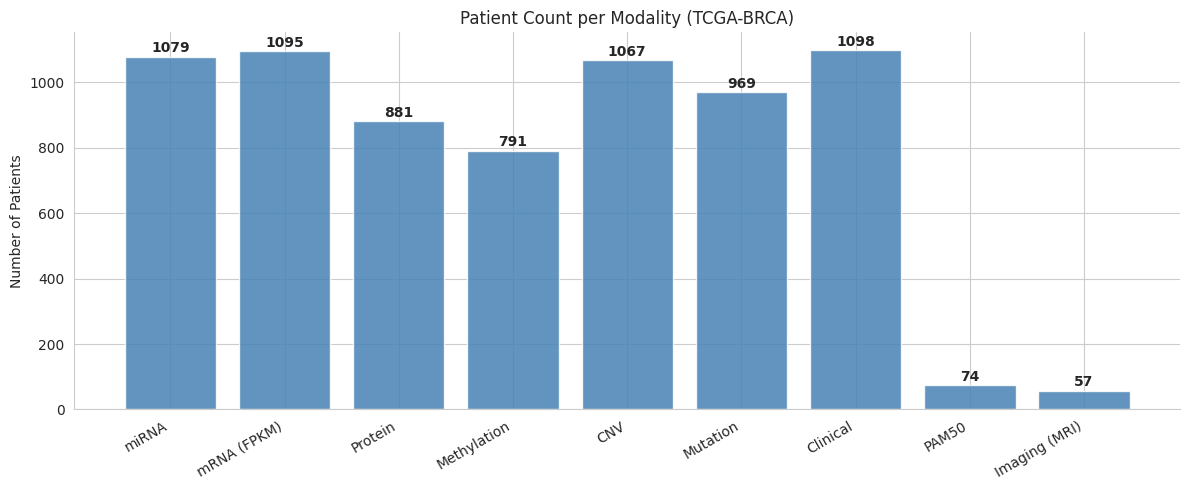

In [5]:
# Bar chart of per-modality counts
names = list(patient_sets.keys())
counts = [len(v) for v in patient_sets.values()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, counts, color='steelblue', edgecolor='white', alpha=0.85)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Count per Modality (TCGA-BRCA)')
ax.set_xticklabels(names, rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Pairwise Overlap Matrix

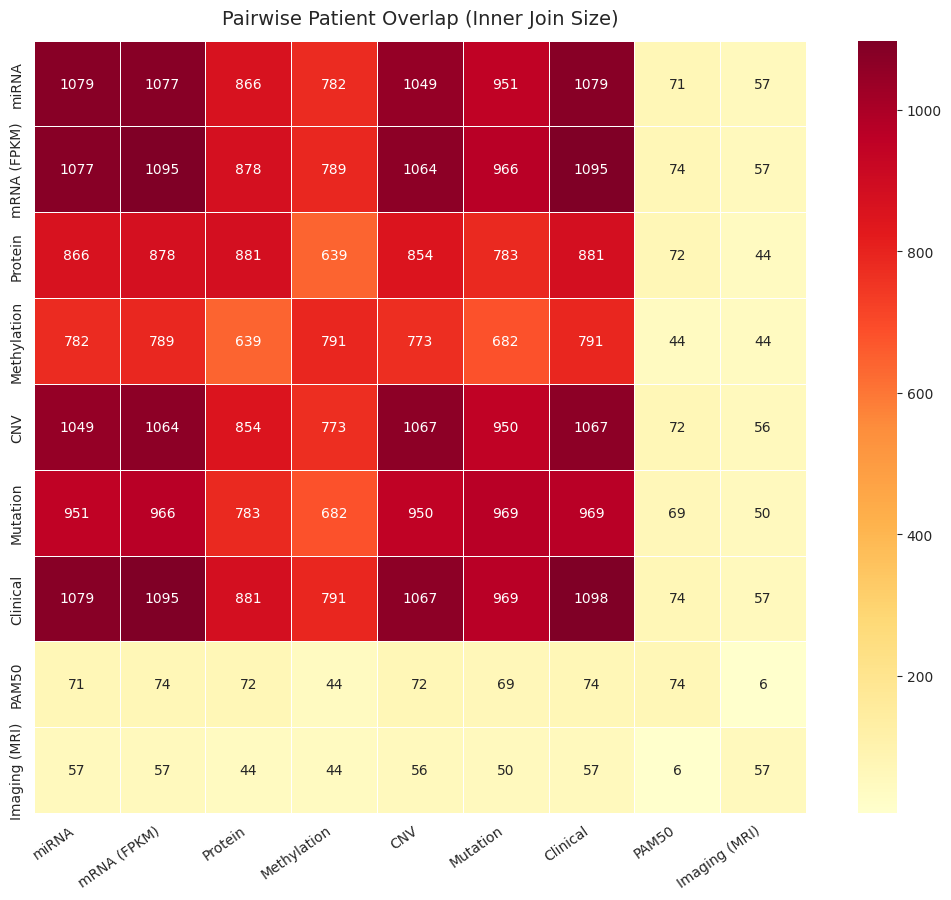


Imaging overlap with each modality:
  miRNA               :  57 / 57 imaging patients (100%)
  mRNA (FPKM)         :  57 / 57 imaging patients (100%)
  Protein             :  44 / 57 imaging patients (77%)
  Methylation         :  44 / 57 imaging patients (77%)
  CNV                 :  56 / 57 imaging patients (98%)
  Mutation            :  50 / 57 imaging patients (88%)
  Clinical            :  57 / 57 imaging patients (100%)
  PAM50               :   6 / 57 imaging patients (11%)


In [6]:
mod_names = list(patient_sets.keys())
n = len(mod_names)
overlap_matrix = np.zeros((n, n), dtype=int)

for i, a in enumerate(mod_names):
    for j, b in enumerate(mod_names):
        overlap_matrix[i, j] = len(patient_sets[a] & patient_sets[b])

overlap_df = pd.DataFrame(overlap_matrix, index=mod_names, columns=mod_names)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(overlap_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle

sns.heatmap(
    overlap_df, annot=True, fmt='d', cmap='YlOrRd',
    ax=ax, linewidths=0.5, square=True,
)
ax.set_title('Pairwise Patient Overlap (Inner Join Size)', fontsize=14, pad=12)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nImaging overlap with each modality:')
for name, ids in patient_sets.items():
    if name != 'Imaging (MRI)':
        overlap = len(imaging_ids & ids)
        pct = overlap / len(imaging_ids) * 100
        print(f'  {name:20s}: {overlap:3d} / {len(imaging_ids)} imaging patients ({pct:.0f}%)')

## 4. Venn Diagram: Core Three-Way Overlap

The three modalities actually used by the current `v1_imaging` config.

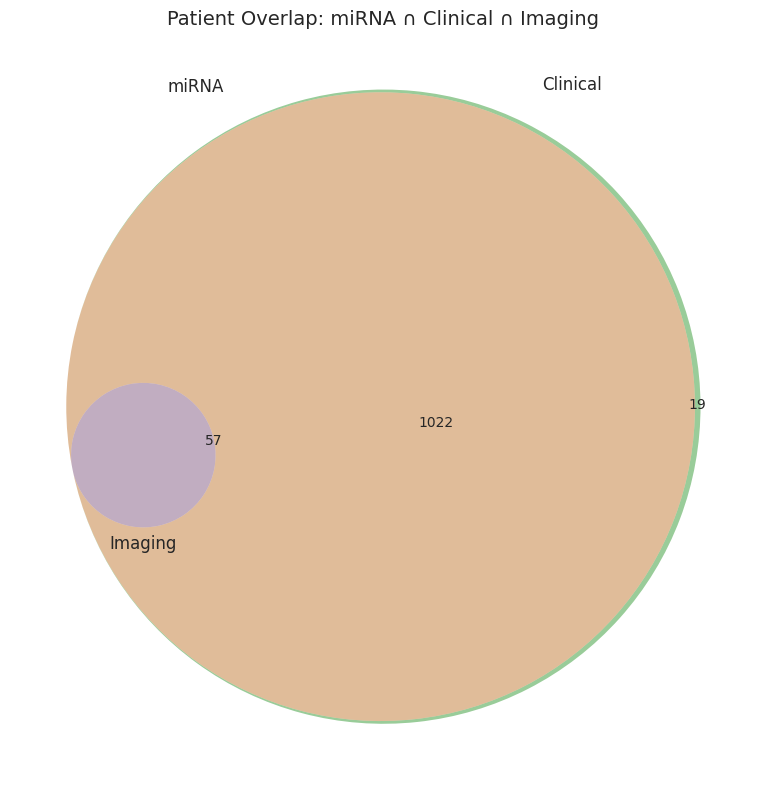

Inner join (all three):            57 patients
Outer union (any modality):      1098 patients
Data lost by inner join:         1041 patients (94.8%)


In [7]:
try:
    from matplotlib_venn import venn3
    has_venn = True
except ImportError:
    has_venn = False
    print('matplotlib_venn not installed; install with: pip install matplotlib-venn')

if has_venn and all(k in patient_sets for k in ('miRNA', 'Clinical', 'Imaging (MRI)')):
    mirna_ids = patient_sets['miRNA']
    clin_ids  = patient_sets['Clinical']
    img_ids   = patient_sets['Imaging (MRI)']

    fig, ax = plt.subplots(figsize=(8, 8))
    v = venn3(
        [mirna_ids, clin_ids, img_ids],
        set_labels=('miRNA', 'Clinical', 'Imaging'),
        ax=ax,
    )
    ax.set_title('Patient Overlap: miRNA ∩ Clinical ∩ Imaging', fontsize=14)
    plt.tight_layout()
    plt.show()

    inner = mirna_ids & clin_ids & img_ids
    outer = mirna_ids | clin_ids | img_ids
    print(f'Inner join (all three):          {len(inner):4d} patients')
    print(f'Outer union (any modality):      {len(outer):4d} patients')
    print(f'Data lost by inner join:         {len(outer) - len(inner):4d} patients ({(len(outer)-len(inner))/len(outer)*100:.1f}%)')

## 5. ID Normalisation Impact

Show how many patients are recovered just by normalising sample-level IDs to patient-level.

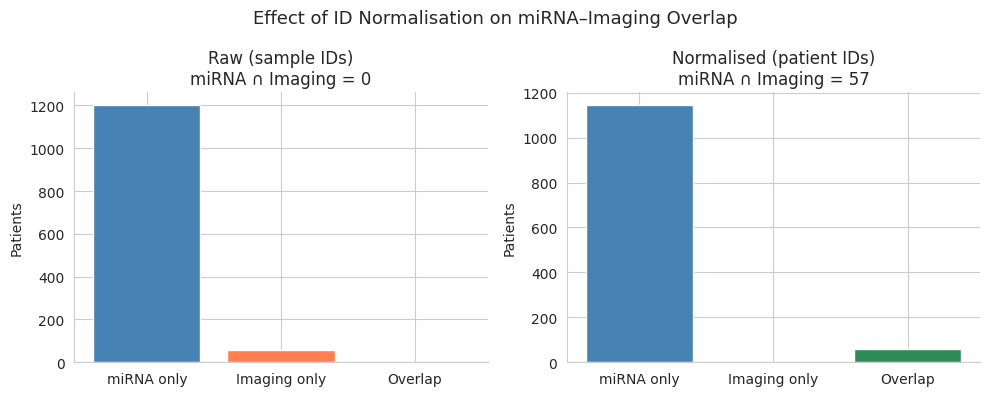

miRNA raw sample IDs:      1202
miRNA normalised patient:  1079
Overlap before norm:       0
Overlap after norm:        57


In [8]:
# Raw (without normalisation)
df_mirna_head = pd.read_csv(DATA_DIR / 'TCGA-BRCA.mirna.tsv', sep='\t', nrows=0)
mirna_raw_ids = set(c for c in df_mirna_head.columns if c.startswith('TCGA'))
mirna_norm_ids = set(sample_to_patient(c) for c in mirna_raw_ids)

# Overlap with TCIA — before and after normalisation
overlap_raw  = len(mirna_raw_ids & imaging_ids)
overlap_norm = len(mirna_norm_ids & imaging_ids)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, ov) in zip(axes, [('Raw (sample IDs)', overlap_raw), ('Normalised (patient IDs)', overlap_norm)]):
    ax.bar(['miRNA only', 'Imaging only', 'Overlap'],
           [len(mirna_raw_ids) - ov, len(imaging_ids) - ov, ov],
           color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
    ax.set_title(f'{label}\nmiRNA ∩ Imaging = {ov}')
    ax.set_ylabel('Patients')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Effect of ID Normalisation on miRNA–Imaging Overlap', fontsize=13)
plt.tight_layout()
plt.show()

print(f'miRNA raw sample IDs:      {len(mirna_raw_ids)}')
print(f'miRNA normalised patient:  {len(mirna_norm_ids)}')
print(f'Overlap before norm:       {overlap_raw}')
print(f'Overlap after norm:        {overlap_norm}')

## 6. Missingness Pattern Under Outer Join

Visualise which patients are missing which modalities when we use an outer (union) join.

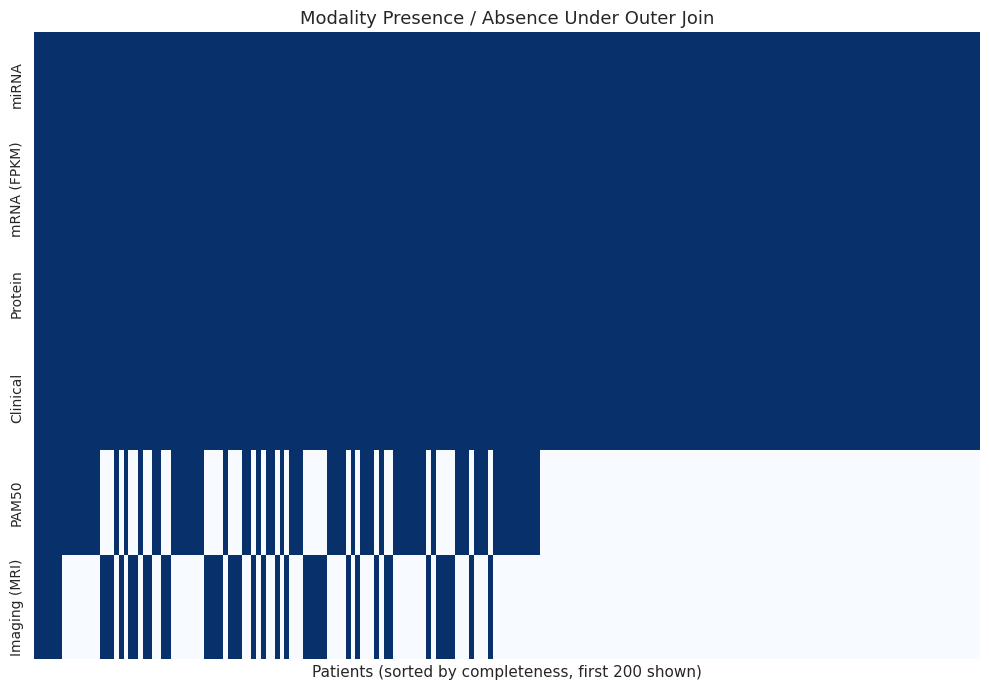


Completeness distribution (how many modalities per patient):
n_mods
2      5
3    211
4    775
5    101
6      6
Name: count, dtype: int64

Total patients in outer join: 1098
Patients with ALL modalities: 6


In [9]:
# Build a presence/absence matrix for a representative subset of modalities
core_modalities = ['miRNA', 'mRNA (FPKM)', 'Protein', 'Clinical', 'PAM50', 'Imaging (MRI)']
available_mods = {k: patient_sets[k] for k in core_modalities if k in patient_sets}

all_patients = sorted(set.union(*available_mods.values()))
presence = pd.DataFrame(
    {mod: [1 if pid in ids else 0 for pid in all_patients]
     for mod, ids in available_mods.items()},
    index=all_patients,
)

# Sort rows by number of modalities present (desc)
presence['n_mods'] = presence.sum(axis=1)
presence = presence.sort_values('n_mods', ascending=False)

# Missingness heatmap (sample of patients for readability)
sample_size = min(200, len(presence))
sampled = presence.drop(columns='n_mods').iloc[:sample_size]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    sampled.T, cmap='Blues', cbar=False,
    linewidths=0,
    xticklabels=False,
    yticklabels=True,
    ax=ax,
)
ax.set_xlabel(f'Patients (sorted by completeness, first {sample_size} shown)', fontsize=11)
ax.set_title('Modality Presence / Absence Under Outer Join', fontsize=13)
plt.tight_layout()
plt.show()

# Distribution of modality completeness
print('\nCompleteness distribution (how many modalities per patient):')
print(presence['n_mods'].value_counts().sort_index())
print(f'\nTotal patients in outer join: {len(presence)}')
print(f'Patients with ALL modalities: {(presence["n_mods"] == len(available_mods)).sum()}')

## 7. Join Strategies: Sample Count Comparison

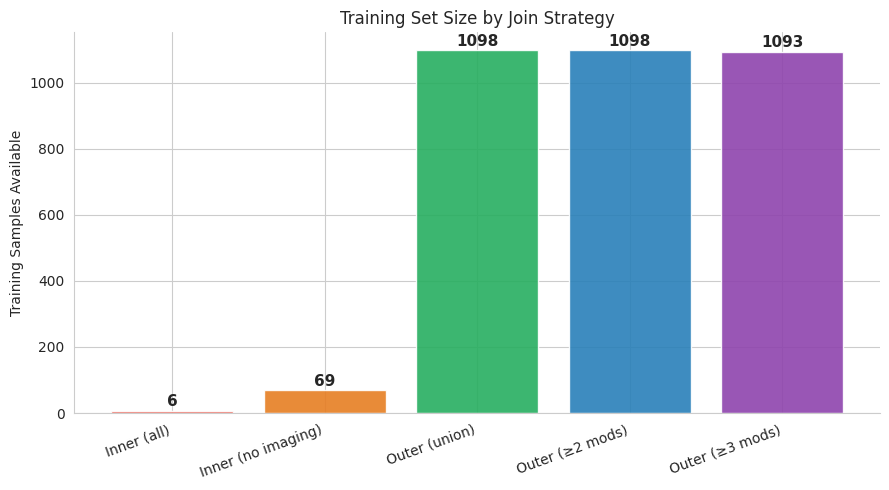

In [10]:
strategies = {}

# Inner join (all modalities)
inner_all = set.intersection(*available_mods.values())
strategies['Inner (all)'] = len(inner_all)

# Inner join without imaging
no_img = {k: v for k, v in available_mods.items() if k != 'Imaging (MRI)'}
if no_img:
    inner_no_img = set.intersection(*no_img.values())
    strategies['Inner (no imaging)'] = len(inner_no_img)

# Outer join (union)
strategies['Outer (union)'] = len(all_patients)

# Outer join patients with ≥2 modalities
strategies['Outer (≥2 mods)'] = int((presence['n_mods'] >= 2).sum())

# Outer join patients with ≥3 modalities
strategies['Outer (≥3 mods)'] = int((presence['n_mods'] >= 3).sum())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9', '#8e44ad']
bars = ax.bar(list(strategies.keys()), list(strategies.values()),
              color=colors[:len(strategies)], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, strategies.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Training Samples Available')
ax.set_title('Training Set Size by Join Strategy')
ax.set_xticklabels(list(strategies.keys()), rotation=20, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Imputation Strategies for Missing Modalities

Under an **outer join**, patients with missing modalities need a strategy:

| Strategy | Description | Pros | Cons |
|---|---|---|---|
| **Zero imputation** | Fill missing modality with zeros | Simple | Zeros ≠ biological zero; corrupts gate |
| **Mean imputation** | Fill with feature-wise mean from present patients | Statistically neutral | Loses individual variation |
| **Modality masking** | Pass a boolean mask alongside inputs; zero-fill + mask flag | Model can learn to ignore | Requires architecture support |
| **Conditional VAE** | Learn a latent that can be decoded for missing mods | Most biologically principled | Complex, needs enough data |
| **Separate heads** | Train unimodal heads; fuse only when both present | No assumptions about missing data | Can't leverage paired signal |

The **modality masking** approach is recommended for this project because:
1. The existing `GatedLateFusionModule` already has a gating network — it can learn to down-weight masked modalities.
2. The `modality_dropout_prob` config already approximates this during training.
3. Implementation only requires adding a `modality_mask` tensor to each batch.

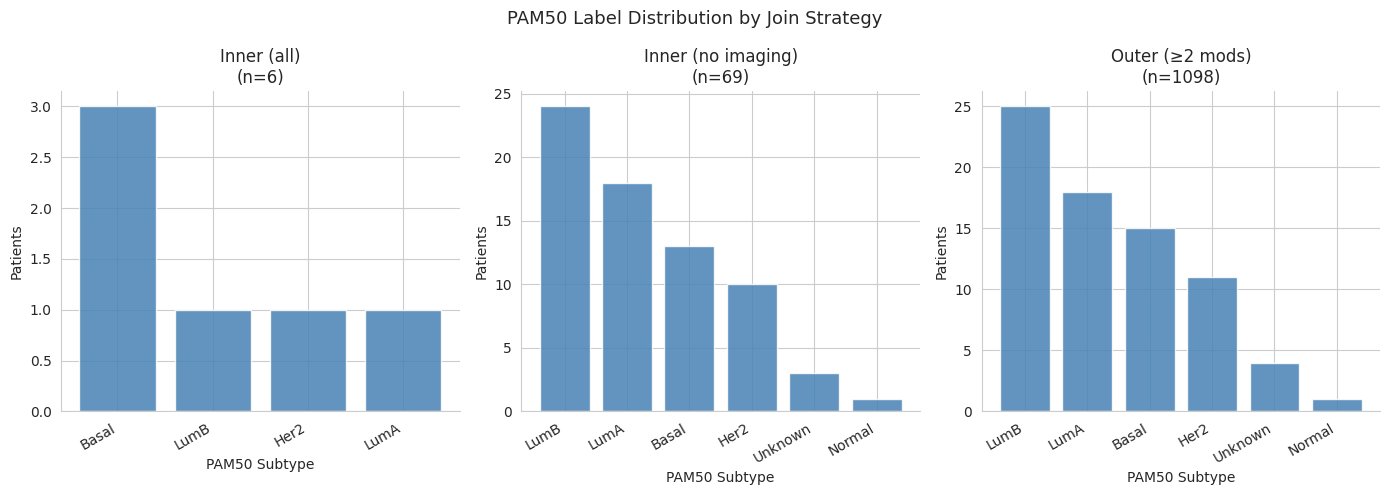

In [11]:
# Simulate: how does class distribution change across join strategies?
pam50_path = DATA_DIR / 'pam50.tsv'
if pam50_path.exists():
    pam50_df = pd.read_csv(pam50_path, sep='\t')
    pam50_df['patient_id'] = pam50_df['sample'].apply(sample_to_patient)
    pam50_df = pam50_df.drop_duplicates('patient_id').set_index('patient_id')

    join_sets = {
        'Inner (all)': inner_all,
        'Inner (no imaging)': inner_no_img,
        'Outer (≥2 mods)': set(presence[presence['n_mods'] >= 2].index),
    }

    fig, axes = plt.subplots(1, len(join_sets), figsize=(14, 5), sharey=False)
    for ax, (strat_name, patient_set) in zip(axes, join_sets.items()):
        labels = pam50_df.loc[pam50_df.index.isin(patient_set), 'PAM50'].value_counts()
        if labels.empty:
            ax.text(0.5, 0.5, 'No PAM50\nlabels available', ha='center', va='center')
            ax.axis('off')
        else:
            ax.bar(labels.index, labels.values, color='steelblue', edgecolor='white', alpha=0.85)
            ax.set_title(f'{strat_name}\n(n={len(patient_set)})')
            ax.set_xlabel('PAM50 Subtype')
            ax.set_ylabel('Patients')
            ax.set_xticklabels(labels.index, rotation=30, ha='right')
            ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('PAM50 Label Distribution by Join Strategy', fontsize=13)
    plt.tight_layout()
    plt.show()

## 9. Recommended Path Forward

### Short-term (fix current inner join)
1. **Normalise patient IDs** — truncate sample-level `TCGA-XX-XXXX-01A` to `TCGA-XX-XXXX` in `xenabrowser_parser.py` and `ImageDataModule` before joining.
2. **Generate shared split files** from the normalised intersection so splits are consistent across modalities.

### Medium-term (outer join + masking)
1. Add `strategy='outer'` support to `MultimodalDataset._build_index()`.
2. Pass a `modality_mask: Dict[str, bool]` tensor in each batch item.
3. Update `GatedLateFusionModule.forward()` to zero-out missing encoders and multiply gate weights by the mask before softmax.
4. This unlocks ~1200+ patients for gene+clinical training, with imaging used only for the 57 patients that have it.

### Data available with outer join
```
miRNA + Clinical alone:   ~198 patients  (current bottleneck without imaging)
miRNA + Clinical + Image: ~57  patients  (imaging-complete cohort)
All patients (any mod):   ~1229 patients
```

## 10. Stage Label Distribution & "Unknown" Impact

How many patients are gained/lost by including or excluding `Unknown` stage, across join strategies.

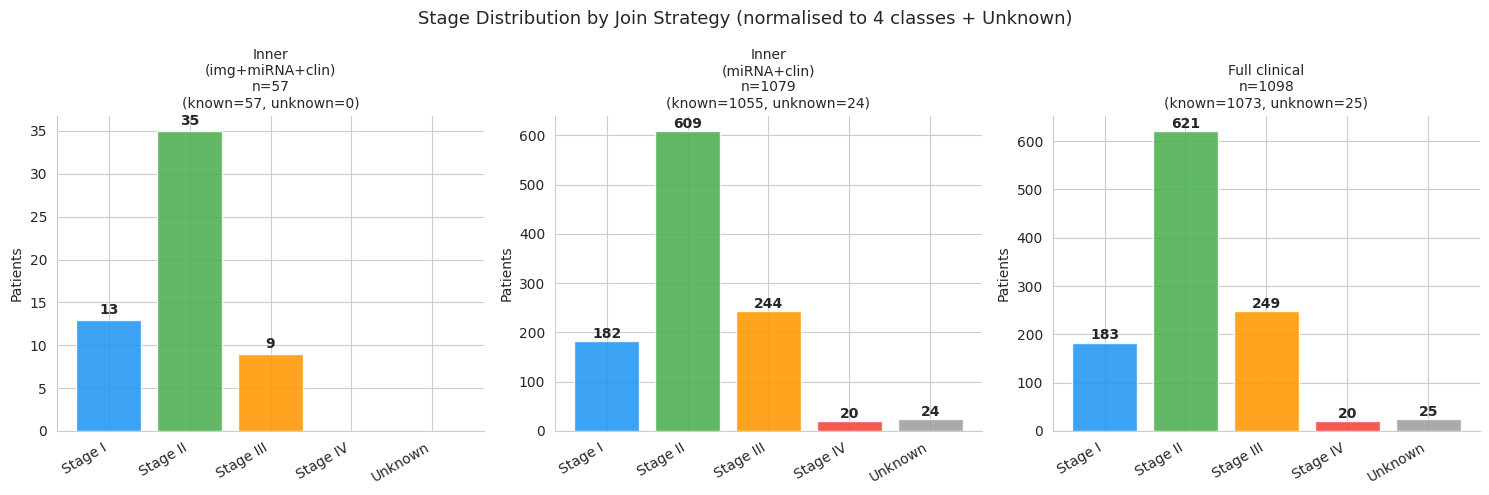

In [12]:
import re

def normalize_stage(s):
    """Normalise raw TCGA stage string to Stage I/II/III/IV/Unknown."""
    if pd.isna(s) or str(s).strip() == '':
        return 'Unknown'
    s = str(s).strip().lower()
    for roman in ['iv', 'iii', 'ii', 'i']:
        if roman in s:
            return f'Stage {roman.upper()}'
    return 'Unknown'

# Load and deduplicate clinical (one row per patient)
clin_df = pd.read_csv(DATA_DIR / 'TCGA-BRCA.clinical.tsv', sep='\t')
clin_df['patient_id'] = clin_df['sample'].apply(sample_to_patient)
clin_df['stage_norm'] = clin_df['ajcc_pathologic_stage.diagnoses'].apply(normalize_stage)
clin_dedup = clin_df.drop_duplicates('patient_id').set_index('patient_id')

# ── Define join cohorts ──────────────────────────────────────────────────────
mirna_ids  = patient_sets['miRNA']
clin_ids   = set(clin_dedup.index)
img_ids    = patient_sets['Imaging (MRI)']

cohorts = {
    'Inner\n(img+miRNA+clin)\nn=57':  img_ids & mirna_ids & clin_ids,
    'Inner\n(miRNA+clin)\nn=1079':    mirna_ids & clin_ids,
    'Full clinical\nn=1098':          clin_ids,
}

STAGE_ORDER   = ['Stage I', 'Stage II', 'Stage III', 'Stage IV', 'Unknown']
STAGE_COLOURS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9E9E9E']

fig, axes = plt.subplots(1, len(cohorts), figsize=(15, 5), sharey=False)

for ax, (title, pids) in zip(axes, cohorts.items()):
    stages = clin_dedup.loc[clin_dedup.index.isin(pids), 'stage_norm']
    counts = stages.value_counts().reindex(STAGE_ORDER, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=STAGE_COLOURS[:len(counts)], edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    unknown_n = counts.get('Unknown', 0)
    known_n   = counts.drop('Unknown', errors='ignore').sum()
    ax.set_title(f'{title}\n(known={known_n}, unknown={unknown_n})', fontsize=10)
    ax.set_xticklabels(counts.index, rotation=30, ha='right')
    ax.set_ylabel('Patients')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Stage Distribution by Join Strategy (normalised to 4 classes + Unknown)', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Summary table: size with vs without Unknown, per cohort
print(f"{'Cohort':<35} {'w/ Unknown':>12} {'w/o Unknown':>12} {'Lost':>6}")
print('-' * 67)
for title, pids in cohorts.items():
    label = title.replace('\n', ' ')
    stages = clin_dedup.loc[clin_dedup.index.isin(pids), 'stage_norm']
    total  = len(stages)
    known  = (stages != 'Unknown').sum()
    print(f"{label:<35} {total:>12} {known:>12} {total-known:>6}")

print()
print("Key finding:")
print("  - 57-patient imaging cohort:  0 Unknown patients — dropping Unknown has NO effect here.")
print("  - miRNA+Clinical (1079):     24 Unknown — excluding them gives 1055 patients (−2.2%).")
print("  - Stage IV appears only in the broader cohort; absent from imaging patients.")
print("  - Including Unknown as a 5th class is feasible for the tabular-only pipeline.")

Cohort                                w/ Unknown  w/o Unknown   Lost
-------------------------------------------------------------------
Inner (img+miRNA+clin) n=57                   57           57      0
Inner (miRNA+clin) n=1079                   1079         1055     24
Full clinical n=1098                        1098         1073     25

Key finding:
  - 57-patient imaging cohort:  0 Unknown patients — dropping Unknown has NO effect here.
  - miRNA+Clinical (1079):     24 Unknown — excluding them gives 1055 patients (−2.2%).
  - Stage IV appears only in the broader cohort; absent from imaging patients.
  - Including Unknown as a 5th class is feasible for the tabular-only pipeline.


## 11. cBioPortal PAM50 vs XenaBrowser PAM50

Compare the 74-patient `pam50.tsv` from XenaBrowser against the 981-patient PAM50 labels from cBioPortal's PanCancer Atlas 2018 study (`brca_tcga_pan_can_atlas_2018`).

Data downloaded via `oncolearn download --cbioportal --cohorts BRCA`.

In [14]:
from oncolearn.api.cbioportal.builder import CBioPortalCohortBuilder

CBIO_DIR = Path('/home/andrew/OncoLearn/data/cbioportal/TCGA-BRCA')
CBIO_DIR.mkdir(parents=True, exist_ok=True)

# ── Download PAM50 from cBioPortal if not already present ────────────────────
cbio_pam50_path = CBIO_DIR / 'TCGA-BRCA.pam50_pancancer.tsv'
if not cbio_pam50_path.exists():
    print("Downloading PAM50 from cBioPortal PanCancer Atlas…")
    builder = CBioPortalCohortBuilder()
    cohort = builder.build_cohort('BRCA')
    pam50_ds = next(ds for ds in cohort.datasets if ds.name == 'pam50_subtype')
    pam50_ds.download(str(CBIO_DIR), confirm=False)
else:
    print(f"Using cached: {cbio_pam50_path}")

# ── Load both sources ─────────────────────────────────────────────────────────
cbio_pam50 = pd.read_csv(cbio_pam50_path, sep='\t')
cbio_pam50 = cbio_pam50.rename(columns={'sample': 'patient_id', 'SUBTYPE': 'pam50_cbio'})
cbio_pam50['patient_id'] = cbio_pam50['patient_id'].apply(sample_to_patient)

xena_pam50 = pd.read_csv(DATA_DIR / 'pam50.tsv', sep='\t')
xena_pam50['patient_id'] = xena_pam50['sample'].apply(sample_to_patient)
xena_pam50 = xena_pam50.drop_duplicates('patient_id').rename(columns={'PAM50': 'pam50_xena'})

print(f"cBioPortal PAM50: {len(cbio_pam50)} patients")
print(f"XenaBrowser PAM50: {len(xena_pam50)} patients")
print(f"\ncBioPortal values: {sorted(cbio_pam50['pam50_cbio'].unique())}")
print(f"XenaBrowser values: {sorted(xena_pam50['pam50_xena'].unique())}")

Using cached: /home/andrew/OncoLearn/data/cbioportal/TCGA-BRCA/TCGA-BRCA.pam50_pancancer.tsv
cBioPortal PAM50: 981 patients
XenaBrowser PAM50: 74 patients

cBioPortal values: ['BRCA_Basal', 'BRCA_Her2', 'BRCA_LumA', 'BRCA_LumB', 'BRCA_Normal']
XenaBrowser values: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal', 'Unknown']


In [15]:
# ── Join and compare on the shared patient set ────────────────────────────────
merged = cbio_pam50.merge(xena_pam50[['patient_id','pam50_xena']], on='patient_id', how='inner')
print(f"Patients in both sources: {len(merged)}")

# Normalise cBioPortal labels (BRCA_LumA → LumA) to match XenaBrowser format
merged['pam50_cbio_short'] = merged['pam50_cbio'].str.replace('BRCA_', '', regex=False)

# Agreement check
merged['agree'] = merged['pam50_cbio_short'] == merged['pam50_xena']
print(f"Label agreement: {merged['agree'].sum()}/{len(merged)} "
      f"({merged['agree'].mean()*100:.1f}%)")

# Show disagreements
if not merged['agree'].all():
    print("\nDisagreements:")
    print(merged[~merged['agree']][['patient_id','pam50_cbio_short','pam50_xena']].to_string())

# Confusion matrix
cm = pd.crosstab(merged['pam50_cbio_short'], merged['pam50_xena'],
                 rownames=['cBioPortal'], colnames=['XenaBrowser'])
print("\nConfusion matrix (cBioPortal rows vs XenaBrowser cols):")
print(cm)

Patients in both sources: 71
Label agreement: 55/71 (77.5%)

Disagreements:
      patient_id pam50_cbio_short pam50_xena
0   TCGA-3C-AALJ             LumB    Unknown
1   TCGA-4H-AAAK             LumA    Unknown
4   TCGA-A2-A0ET             LumA       LumB
12  TCGA-A2-A0T4             LumA       LumB
16  TCGA-A2-A0YC             LumA       LumB
18  TCGA-A2-A0YF             LumA       LumB
29  TCGA-A8-A06N             LumB    Unknown
32  TCGA-AO-A03L             LumA       LumB
34  TCGA-AO-A0J5             LumA       LumB
35  TCGA-AO-A0J8             LumA       LumB
36  TCGA-AO-A0JB           Normal      Basal
46  TCGA-BH-A0B5             LumA       LumB
49  TCGA-BH-A0C1             LumA       LumB
59  TCGA-C8-A12O             LumA       LumB
64  TCGA-C8-A12Y             LumA       LumB
68  TCGA-C8-A8HR           Normal    Unknown

Confusion matrix (cBioPortal rows vs XenaBrowser cols):
XenaBrowser  Basal  Her2  LumA  LumB  Normal  Unknown
cBioPortal                                      

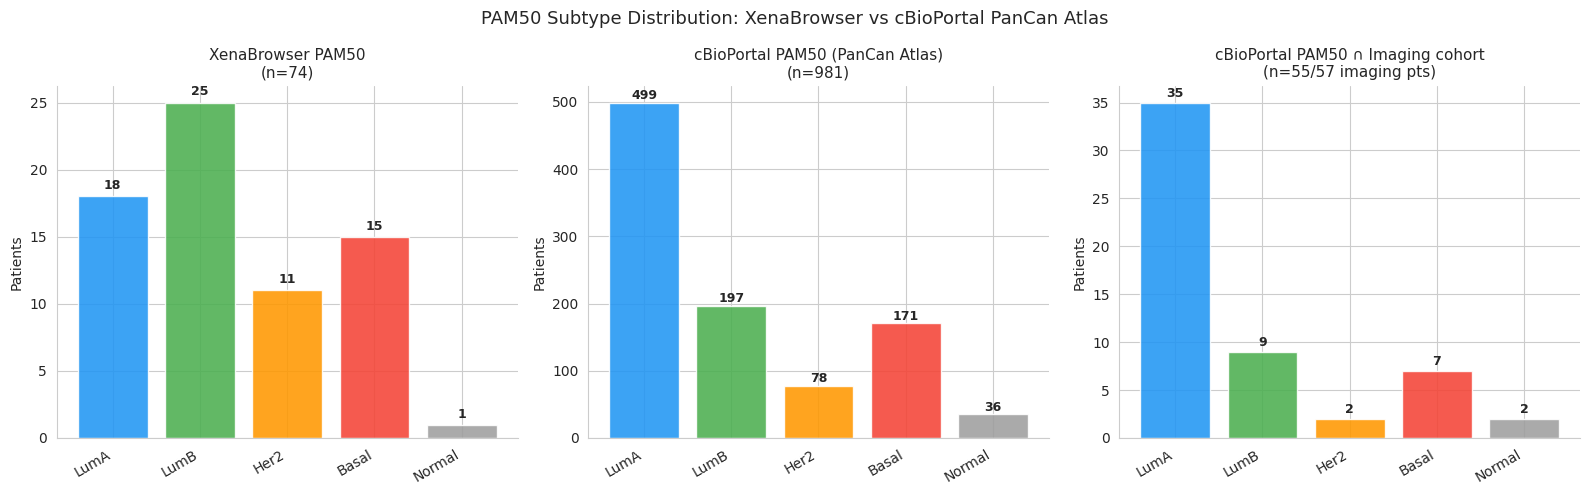


Summary:
  XenaBrowser PAM50 patients:            74
  cBioPortal PAM50 patients:             981
  cBioPortal PAM50 ∩ imaging cohort:     55 / 57
  XenaBrowser PAM50 ∩ imaging cohort:    6 / 57

  → cBioPortal covers 96% of the imaging cohort vs 11% for XenaBrowser


In [16]:
# ── Coverage comparison: cBioPortal vs imaging cohort ────────────────────────
cbio_ids   = set(cbio_pam50['patient_id'])
img_pam50  = cbio_ids & img_ids
xena_pam50_ids = set(xena_pam50['patient_id'])
xena_img   = xena_pam50_ids & img_ids

SUBTYPE_ORDER = ['LumA', 'LumB', 'Her2', 'Basal', 'Normal']
SUBTYPE_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9E9E9E']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. XenaBrowser full set
xena_counts = xena_pam50['pam50_xena'].value_counts().reindex(
    [s for s in SUBTYPE_ORDER if s in xena_pam50['pam50_xena'].unique()], fill_value=0)
axes[0].bar(xena_counts.index, xena_counts.values,
            color=[SUBTYPE_COLORS[SUBTYPE_ORDER.index(s)] for s in xena_counts.index],
            edgecolor='white', alpha=0.88)
axes[0].set_title(f'XenaBrowser PAM50\n(n={len(xena_pam50)})', fontsize=11)

# 2. cBioPortal full set (short labels)
cbio_short = cbio_pam50['pam50_cbio'].str.replace('BRCA_','',regex=False)
cbio_counts = cbio_short.value_counts().reindex(SUBTYPE_ORDER, fill_value=0)
axes[1].bar(cbio_counts.index, cbio_counts.values,
            color=SUBTYPE_COLORS, edgecolor='white', alpha=0.88)
axes[1].set_title(f'cBioPortal PAM50 (PanCan Atlas)\n(n={len(cbio_pam50)})', fontsize=11)

# 3. cBioPortal coverage of imaging cohort
img_cbio_df = cbio_pam50[cbio_pam50['patient_id'].isin(img_ids)].copy()
img_cbio_df['subtype_short'] = img_cbio_df['pam50_cbio'].str.replace('BRCA_','',regex=False)
img_counts = img_cbio_df['subtype_short'].value_counts().reindex(SUBTYPE_ORDER, fill_value=0)
axes[2].bar(img_counts.index, img_counts.values,
            color=SUBTYPE_COLORS, edgecolor='white', alpha=0.88)
axes[2].set_title(f'cBioPortal PAM50 ∩ Imaging cohort\n(n={len(img_cbio_df)}/{len(img_ids)} imaging pts)', fontsize=11)

for ax in axes:
    ax.set_ylabel('Patients')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.spines[['top','right']].set_visible(False)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('PAM50 Subtype Distribution: XenaBrowser vs cBioPortal PanCan Atlas', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  XenaBrowser PAM50 patients:            {len(xena_pam50_ids)}")
print(f"  cBioPortal PAM50 patients:             {len(cbio_ids)}")
print(f"  cBioPortal PAM50 ∩ imaging cohort:     {len(img_pam50)} / {len(img_ids)}")
print(f"  XenaBrowser PAM50 ∩ imaging cohort:    {len(xena_img)} / {len(img_ids)}")
print(f"\n  → cBioPortal covers {len(img_pam50)/len(img_ids)*100:.0f}% of the imaging cohort vs "
      f"{len(xena_img)/len(img_ids)*100:.0f}% for XenaBrowser")